# Interpretabilidad del Modelo - SHAP

En riesgo de crédito, no basta con predecir quién no pagará; debemos entender **por qué**. 
Usaremos **SHAP (SHapley Additive exPlanations)** para desglosar la contribución de cada variable a la predicción final.

In [1]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

## 1. Recarga de Datos y Modelo
Para analizar la interpretabilidad, necesitamos un modelo entrenado. Reentrenaremos rápidamente el XGBoost (el mejor candidato usualmente) con los datos procesados.

In [2]:
# Carga datos
df_sample = pd.read_csv("../data/processed/df_sample.csv")

target_col = "target_bad"
df_model = df_sample.dropna(subset=[target_col]).copy()

# Separar features
leak_cols = [
    "loan_status", "total_pymnt", "total_pymnt_inv", "total_rec_prncp", 
    "total_rec_int", "total_rec_late_fee", "recoveries", 
    "collection_recovery_fee", "last_pymnt_d", "last_pymnt_amnt", 
    "next_pymnt_d", "last_credit_pull_d", "out_prncp", "out_prncp_inv"
]
id_text_cols = ["id", "member_id", "url", "desc", "emp_title", "title"]

exclude = leak_cols + id_text_cols + [target_col]
X_cols = [c for c in df_sample.columns if c not in exclude]

X = df_model[X_cols]
y = df_model[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12345, stratify=y
)

# --- PREPROCESAMIENTO MANUAL PARA SHAP ---
# SHAP funciona mejor si le pasamos el dataframe transformado con nombres de columnas claros.

num_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_features = [c for c in X_train.columns if c not in num_features]

# Imputar numéricas
# SimpleImputer puede eliminar columnas si son todo NaN. Recuperamos los nombres output.
imp_num = SimpleImputer(strategy="median")
X_train_num_val = imp_num.fit_transform(X_train[num_features])
X_test_num_val = imp_num.transform(X_test[num_features])

num_features_out = imp_num.get_feature_names_out(num_features)
X_train_num = pd.DataFrame(X_train_num_val, columns=num_features_out, index=X_train.index)
X_test_num = pd.DataFrame(X_test_num_val, columns=num_features_out, index=X_test.index)

# Encoder categóricas
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_train_cat = enc.fit_transform(X_train[cat_features])
X_test_cat = enc.transform(X_test[cat_features])

cat_names = enc.get_feature_names_out(cat_features)
X_train_cat = pd.DataFrame(X_train_cat, columns=cat_names, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=cat_names, index=X_test.index)

# Unir
X_train_proc = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_proc = pd.concat([X_test_num, X_test_cat], axis=1)

# --- LIMPIEZA DE NOMBRES DE COLUMNAS PARA XGBOOST ---
# XGBoost no permite caracteres como [, ], < en los nombres de features.
import re
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train_proc.columns = [regex.sub("_", c) for c in X_train_proc.columns]
X_test_proc.columns = X_train_proc.columns

# Entrenar XGBoost solo con datos procesados
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train_proc, y_train)


/Users/mauvilar/.venvs/credit_risk_env/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['annual_inc_joint' 'dti_joint' 'verification_status_joint' 'open_acc_6m'
 'open_il_6m' 'open_il_12m' 'open_il_24m' 'mths_since_rcnt_il'
 'total_bal_il' 'il_util' 'open_rv_12m' 'open_rv_24m' 'max_bal_bc'
 'all_util' 'inq_fi' 'total_cu_tl' 'inq_last_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/mauvilar/.venvs/credit_risk_env/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['annual_inc_joint' 'dti_joint' 'verification_status_joint' 'open_acc_6m'
 'open_il_6m' 'open_il_12m' 'open_il_24m' 'mths_since_rcnt_il'
 'total_bal_il' 'il_util' 'open_rv_12m' 'open_rv_24m' 'max_bal_bc'
 'all_util' 'inq_fi' 'total_cu_tl' 'inq_last_12m']. At least one non-missing value is needed for imputation with strategy='median

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

## 2. Importancia Global (Feature Importance)
Calculamos los valores SHAP para el conjunto de prueba. Esto nos dice qué variables son las más influyentes en general.

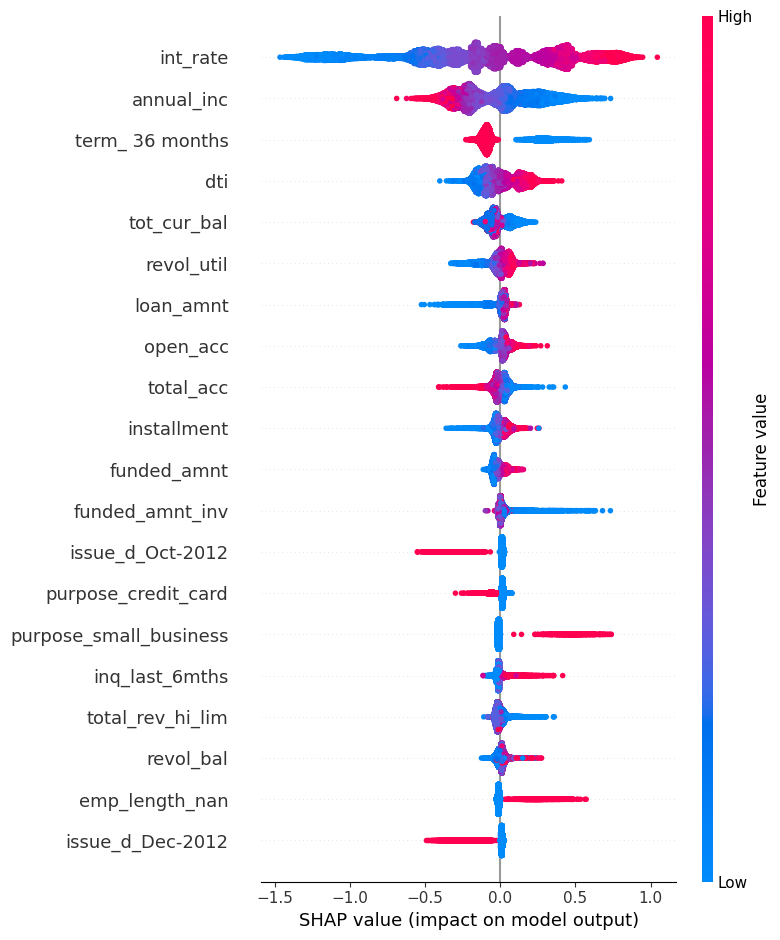

Saved shap_summary.png


<Figure size 640x480 with 0 Axes>

In [3]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test_proc)

plt.figure()
shap.summary_plot(shap_values, X_test_proc, max_display=20)

plt.savefig("../reports/figures/shap_summary.png", bbox_inches="tight")
print("Saved shap_summary.png")

## 3. Interpretación Local (Caso Individual)
Analizamos un caso específico: Un cliente que fue clasificado como de alto riesgo (Target=1). Vemos qué variables empujaron la predicción hacia el riesgo.

Analizando cliente índice 14540 con probabilidad de riesgo: 0.7238


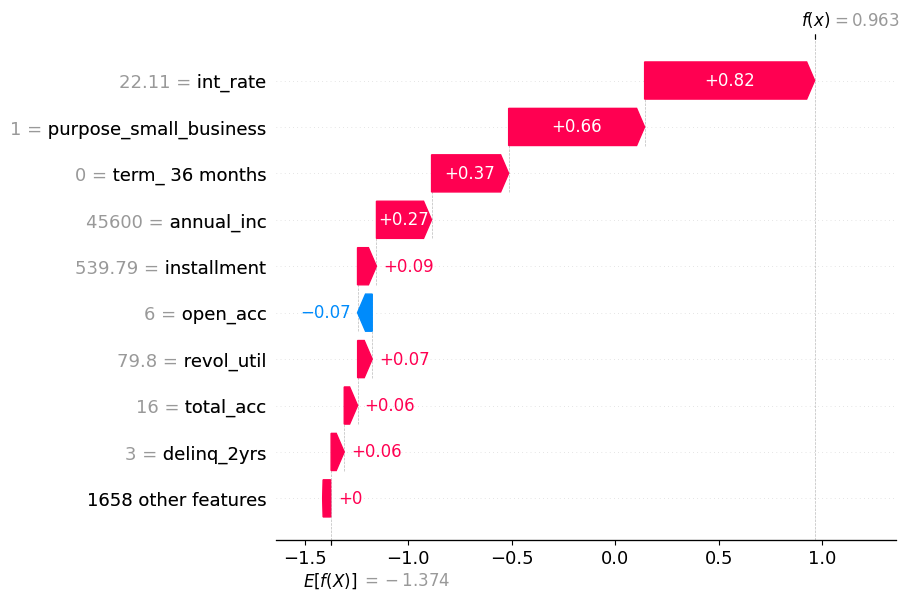

In [4]:
# Buscamos un índice con alta probabilidad de riesgo
probs = model.predict_proba(X_test_proc)[:, 1]
risk_idx = np.argmax(probs) 

print(f"Analizando cliente índice {risk_idx} con probabilidad de riesgo: {probs[risk_idx]:.4f}")

shap.plots.waterfall(shap_values[risk_idx])